In [1]:
# Step 2: Import Libraries and Load Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Customer Churn Dataset
df = pd.read_csv("Telco-Customer-Churn.csv")

# Display Dataset Information
print("Dataset Loaded Successfully!")
print("Dataset Shape:", df.shape)

# Display First 5 Rows
print("\nFirst 5 Rows:")
display(df.head())

Dataset Loaded Successfully!
Dataset Shape: (7043, 21)

First 5 Rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Step 3: Data Understanding and Quality Check

# Dataset shape
print("Dataset Shape:", df.shape)

# Column names
print("\nColumn Names:")
print(df.columns.tolist())

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Customer ID duplicates
print("\nDuplicate Customer IDs:", df["customerID"].duplicated().sum())

# Churn distribution
print("\nChurn Distribution:")
print(df["Churn"].value_counts())

# Dataset information
print("\nDataset Information:")
df.info()


Dataset Shape: (7043, 21)

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing Values:
cus

In [3]:
# Step 4: Data Cleaning - TotalCharges

# Convert TotalCharges to numeric
# Blank or invalid values become NaN
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Check missing values
print("Missing Values in TotalCharges:")
print(df["TotalCharges"].isnull().sum())

# Check duplicate records
print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Check duplicate customer IDs
print("\nDuplicate Customer IDs:")
print(df["customerID"].duplicated().sum())

# Check updated datatype
print("\nTotalCharges Data Type:")
print(df["TotalCharges"].dtype)

# Check rows containing missing TotalCharges
print("\nRows with Missing TotalCharges:")
display(df[df["TotalCharges"].isnull()].head())

Missing Values in TotalCharges:
11

Duplicate Rows:
0

Duplicate Customer IDs:
0

TotalCharges Data Type:
float64

Rows with Missing TotalCharges:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No


In [4]:
# Step 5: Handle Missing Values

# Save original row count
original_rows = len(df)

# Remove rows with missing TotalCharges
df = df.dropna(subset=["TotalCharges"]).copy()

# Reset index
df.reset_index(drop=True, inplace=True)

# Check cleaning results
print("Original Rows:", original_rows)
print("Rows After Cleaning:", len(df))
print("Rows Removed:", original_rows - len(df))

print("\nTotal Missing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nUpdated Dataset Shape:", df.shape)

Original Rows: 7043
Rows After Cleaning: 7032
Rows Removed: 11

Total Missing Values:
0

Duplicate Rows: 0

Updated Dataset Shape: (7032, 21)


Customer Churn Distribution:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Customer Churn Percentage:
Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


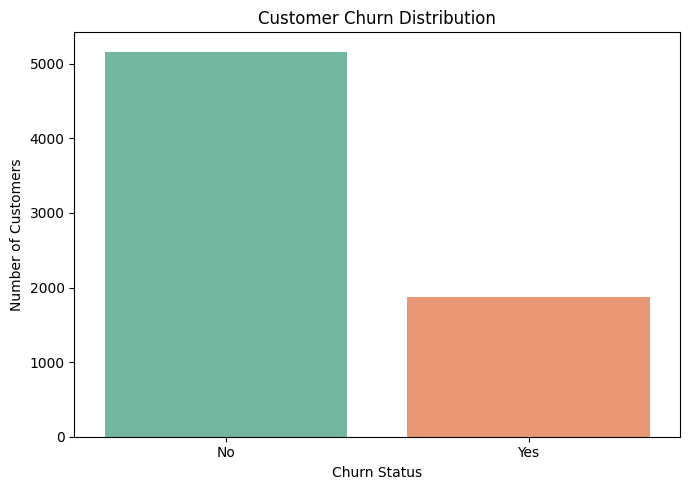

In [5]:
# Step 6: Customer Churn Distribution

# Count customers by churn status
churn_counts = df["Churn"].value_counts()

# Calculate churn percentage
churn_percentage = (
    df["Churn"].value_counts(normalize=True) * 100
)

print("Customer Churn Distribution:")
print(churn_counts)

print("\nCustomer Churn Percentage:")
print(churn_percentage.round(2))

# Visualization
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Churn",
    hue="Churn",
    palette="Set2",
    legend=False
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

Contract Type vs Churn:
Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1306   166
Two year        1637    48

Churn Rate by Contract Type (%):
Contract
Month-to-month    42.71
One year          11.28
Two year           2.85
Name: Churn, dtype: float64


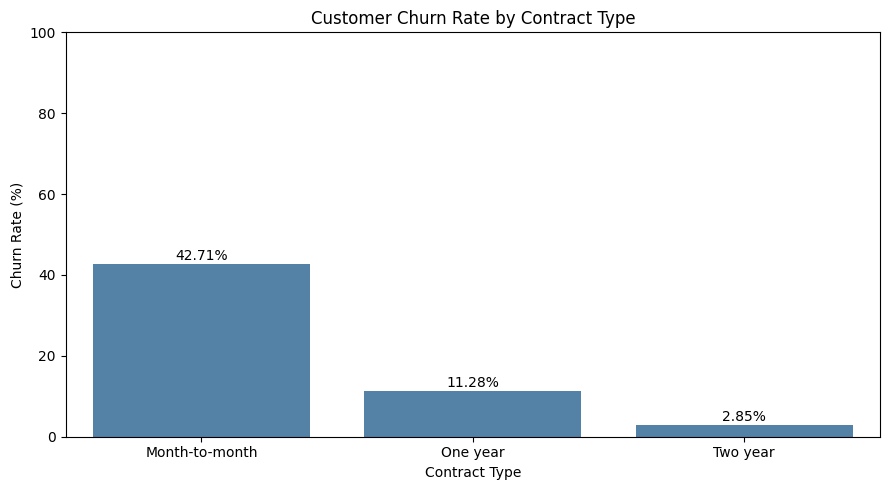

In [6]:
# Step 7: Contract Type vs Customer Churn

# Count customers by contract and churn
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"]
)

print("Contract Type vs Churn:")
print(contract_churn)

# Calculate churn rate for each contract type
contract_churn_rate = (
    df.groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print("\nChurn Rate by Contract Type (%):")
print(contract_churn_rate.round(2))

# Visualization
plt.figure(figsize=(9, 5))

sns.barplot(
    x=contract_churn_rate.index,
    y=contract_churn_rate.values,
    color="steelblue"
)

plt.title("Customer Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 100)

for i, value in enumerate(contract_churn_rate.values):
    plt.text(i, value + 1, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.show()

Monthly Charges Analysis:
       count   mean  median
Churn                      
No      5163  61.31   64.45
Yes     1869  74.44   79.65


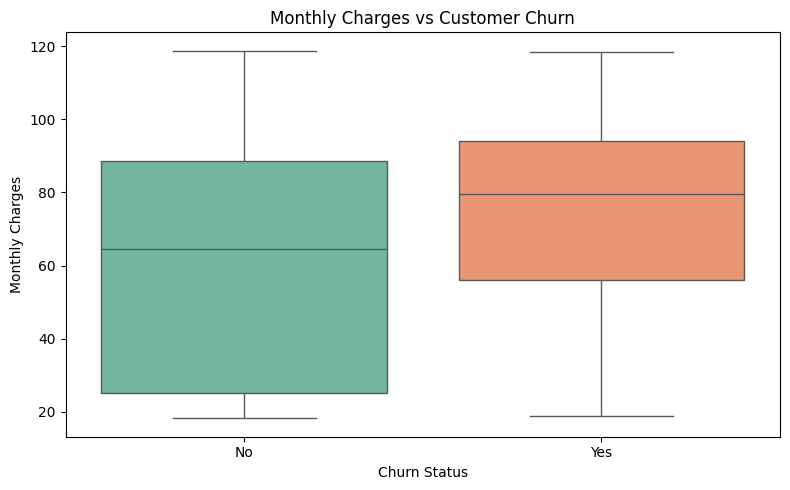

In [7]:
# Step 8: Monthly Charges vs Customer Churn

# Average monthly charges by churn status
monthly_charges = df.groupby("Churn")["MonthlyCharges"].agg(
    ["count", "mean", "median"]
)

print("Monthly Charges Analysis:")
print(monthly_charges.round(2))

# Visualization
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges",
    hue="Churn",
    palette="Set2",
    legend=False
)

plt.title("Monthly Charges vs Customer Churn")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.show()

Customer Tenure Analysis:
       count   mean  median
Churn                      
No      5163  37.65    38.0
Yes     1869  17.98    10.0


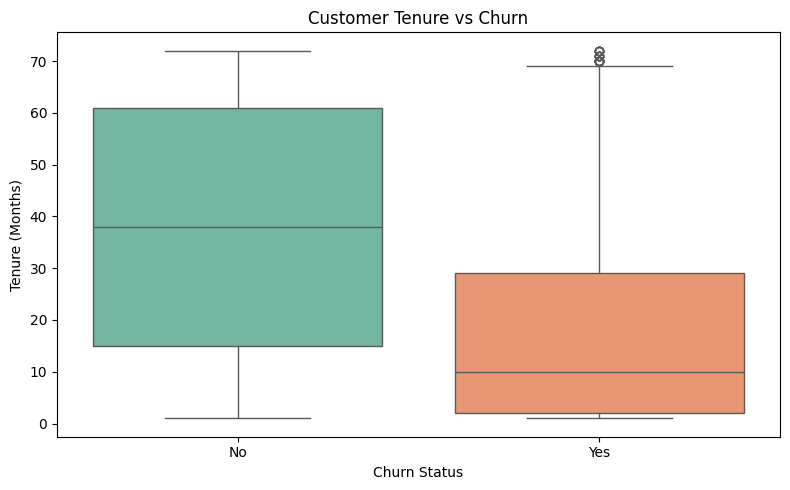

In [8]:
# Step 9: Customer Tenure vs Churn

# Tenure statistics by churn status
tenure_analysis = df.groupby("Churn")["tenure"].agg(
    ["count", "mean", "median"]
)

print("Customer Tenure Analysis:")
print(tenure_analysis.round(2))

# Visualization
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure",
    hue="Churn",
    palette="Set2",
    legend=False
)

plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn Status")
plt.ylabel("Tenure (Months)")

plt.tight_layout()
plt.show()

In [9]:
# Step 10: Feature Selection and Target Preparation

# Remove customer identifier and target column
X = df.drop(columns=["customerID", "Churn"])

# Convert Churn into binary target
y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

# Check features and target
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nTarget Distribution:")
print(y.value_counts())

print("\nMissing Target Values:", y.isnull().sum())

print("\nFeature Columns:")
print(X.columns.tolist())

Features Shape: (7032, 19)
Target Shape: (7032,)

Target Distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64

Missing Target Values: 0

Feature Columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [10]:
# Step 11: Train-Test Split

from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display shapes
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

# Display target distribution
print("\nTraining Target Distribution:")
print(y_train.value_counts())

print("\nTesting Target Distribution:")
print(y_test.value_counts())

Training Features: (5625, 19)
Testing Features: (1407, 19)
Training Target: (5625,)
Testing Target: (1407,)

Training Target Distribution:
Churn
0    4130
1    1495
Name: count, dtype: int64

Testing Target Distribution:
Churn
0    1033
1     374
Name: count, dtype: int64


In [11]:
# Step 12: Data Preprocessing

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Identify categorical and numerical columns
categorical_cols = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Numerical preprocessing
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

print("Numerical Columns:", len(numerical_cols))
print("Categorical Columns:", len(categorical_cols))

print("\nNumerical Features:")
print(numerical_cols)

print("\nCategorical Features:")
print(categorical_cols)

print("\nPreprocessing pipeline created successfully!")

Numerical Columns: 4
Categorical Columns: 15

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Preprocessing pipeline created successfully!


In [12]:
# Step 13: Train Logistic Regression Model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Create Logistic Regression pipeline
lr_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Train the model
lr_model.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test)

# Predict churn probabilities
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

# Evaluate model performance
print("Logistic Regression Results")
print("---------------------------")

print("Accuracy:", round(
    accuracy_score(y_test, y_pred_lr), 4
))

print("Precision:", round(
    precision_score(y_test, y_pred_lr), 4
))

print("Recall:", round(
    recall_score(y_test, y_pred_lr), 4
))

print("F1 Score:", round(
    f1_score(y_test, y_pred_lr), 4
))

print("ROC-AUC:", round(
    roc_auc_score(y_test, y_prob_lr), 4
))

Logistic Regression Results
---------------------------
Accuracy: 0.8038
Precision: 0.6485
Recall: 0.5722
F1 Score: 0.608
ROC-AUC: 0.8359


In [13]:
# Step 14: Train Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

# Create Random Forest pipeline
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

# Train model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Predict churn probabilities
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluate model
print("Random Forest Results")
print("---------------------------")

print("Accuracy:", round(
    accuracy_score(y_test, y_pred_rf), 4
))

print("Precision:", round(
    precision_score(y_test, y_pred_rf), 4
))

print("Recall:", round(
    recall_score(y_test, y_pred_rf), 4
))

print("F1 Score:", round(
    f1_score(y_test, y_pred_rf), 4
))

print("ROC-AUC:", round(
    roc_auc_score(y_test, y_prob_rf), 4
))

Random Forest Results
---------------------------
Accuracy: 0.7839
Precision: 0.6232
Recall: 0.4733
F1 Score: 0.538
ROC-AUC: 0.812


In [14]:
# Step 16: Model Comparison Using Cross-Validation

import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model
}

results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "precision": "precision",
            "recall": "recall",
            "f1": "f1",
            "roc_auc": "roc_auc"
        },
        n_jobs=-1
    )

    results.append({
        "Model": name,
        "Accuracy": round(scores["test_accuracy"].mean(), 4),
        "Precision": round(scores["test_precision"].mean(), 4),
        "Recall": round(scores["test_recall"].mean(), 4),
        "F1 Score": round(scores["test_f1"].mean(), 4),
        "ROC-AUC": round(scores["test_roc_auc"].mean(), 4)
    })

cv_results = pd.DataFrame(results)

print("5-Fold Cross-Validation Results")
print(cv_results.to_string(index=False))

5-Fold Cross-Validation Results
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.8025     0.6541  0.5465    0.5953   0.8461
      Random Forest    0.7963     0.6544  0.4950    0.5634   0.8251


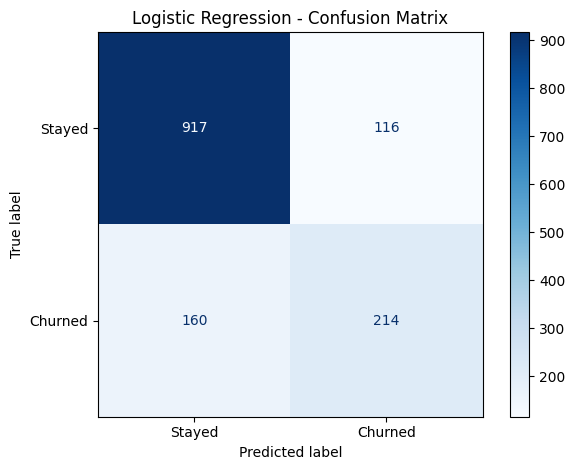

True Negatives: 917
False Positives: 116
False Negatives: 160
True Positives: 214


In [15]:
# Step 18: Logistic Regression Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Churned"]
)

disp.plot(cmap="Blues", values_format="d")

plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

# Print results
print("True Negatives:", cm[0, 0])
print("False Positives:", cm[0, 1])
print("False Negatives:", cm[1, 0])
print("True Positives:", cm[1, 1])

Top 15 Features by Absolute Coefficient:
                                  Feature  Coefficient  Absolute_Coefficient
                              num__tenure    -1.352313              1.352313
                   cat__Contract_Two year    -0.779030              0.779030
                        num__TotalCharges     0.644014              0.644014
                 cat__InternetService_DSL    -0.616132              0.616132
             cat__Contract_Month-to-month     0.613846              0.613846
         cat__InternetService_Fiber optic     0.590184              0.590184
                      num__MonthlyCharges    -0.541006              0.541006
                 cat__PaperlessBilling_No    -0.300387              0.300387
                    cat__MultipleLines_No    -0.293470              0.293470
    cat__OnlineBackup_No internet service    -0.283724              0.283724
     cat__StreamingTV_No internet service    -0.283724              0.283724
     cat__TechSupport_No internet s

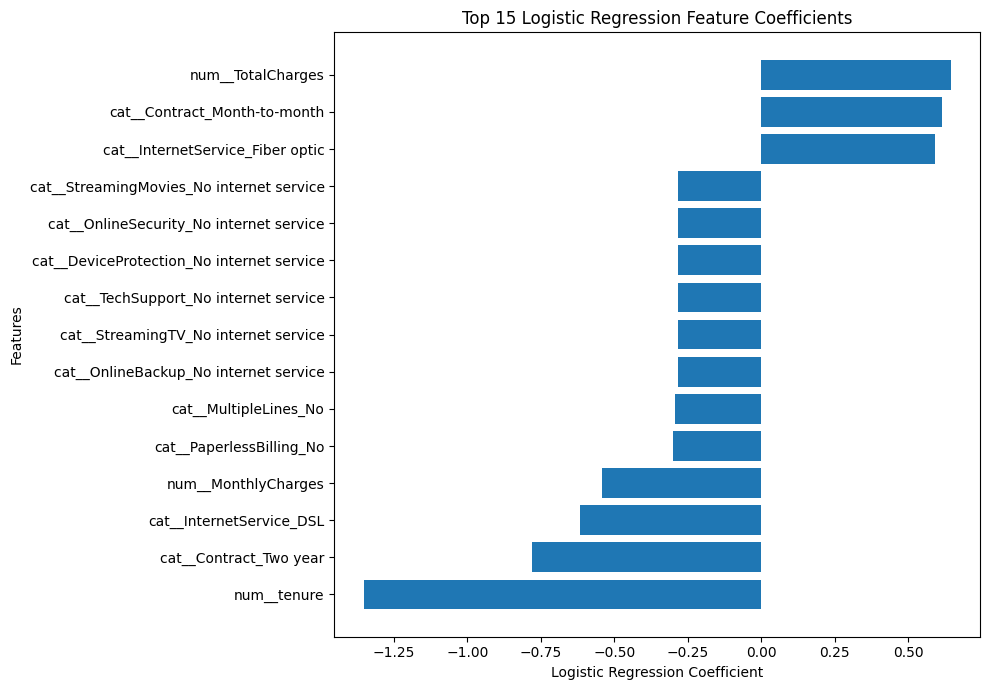

In [16]:
# Step 19: Logistic Regression Feature Coefficients

import pandas as pd
import matplotlib.pyplot as plt

# Get trained preprocessing pipeline
fitted_preprocessor = lr_model.named_steps["preprocessor"]

# Get trained Logistic Regression classifier
classifier = lr_model.named_steps["classifier"]

# Extract feature names
feature_names = fitted_preprocessor.get_feature_names_out()

# Extract coefficients
coefficients = classifier.coef_[0]

# Create DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Calculate absolute coefficients
feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

# Sort features
feature_importance = feature_importance.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

# Display top 15
print("Top 15 Features by Absolute Coefficient:")
print(feature_importance.head(15).to_string(index=False))

# Visualization
top_features = feature_importance.head(15).sort_values(
    by="Coefficient"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Features")
plt.title("Top 15 Logistic Regression Feature Coefficients")

plt.tight_layout()
plt.show()

In [17]:
# Step 20: Save Trained Customer Churn Prediction Model

import joblib
import numpy as np

# Save complete pipeline including preprocessing
joblib.dump(
    lr_model,
    "customer_churn_model.pkl"
)

print("Model saved successfully!")
print("File: customer_churn_model.pkl")

# Load saved model to verify
loaded_model = joblib.load(
    "customer_churn_model.pkl"
)

# Verify predictions
original_predictions = lr_model.predict(X_test)
loaded_predictions = loaded_model.predict(X_test)

print(
    "Predictions match:",
    np.array_equal(original_predictions, loaded_predictions)
)

Model saved successfully!
File: customer_churn_model.pkl
Predictions match: True


In [18]:
# Step 21: Save Model Comparison Results

# Save cross-validation results
cv_results.to_csv(
    "model_comparison_results.csv",
    index=False
)

print("Model comparison results saved successfully!")

# Identify best model by F1 Score
best_model = cv_results.loc[
    cv_results["F1 Score"].idxmax()
]

print("\nBest Model:", best_model["Model"])
print("Accuracy:", best_model["Accuracy"])
print("Precision:", best_model["Precision"])
print("Recall:", best_model["Recall"])
print("F1 Score:", best_model["F1 Score"])
print("ROC-AUC:", best_model["ROC-AUC"])

Model comparison results saved successfully!

Best Model: Logistic Regression
Accuracy: 0.8025
Precision: 0.6541
Recall: 0.5465
F1 Score: 0.5953
ROC-AUC: 0.8461
